 Data loading and cleaning

In [1]:
import pandas as pd
import numpy as np
import os

print("📂 Loading sensor feature dataset...")

file_path = "../data/processed/df_sensor_features.csv"

if not os.path.exists(file_path):
    raise FileNotFoundError("df_sensor_features.csv not found")

df = pd.read_csv(file_path)

print(f"✅ Loaded dataset shape: {df.shape}")
df.head()

📂 Loading sensor feature dataset...
✅ Loaded dataset shape: (18, 16)


,sensor,mean,std,skew,kurtosis,num_peaks,nunique,category,avg_distribution_shift,rolling_mean_std,rolling_std_mean,trend_strength,sensor_score,final_category,score_norm,final_interpretation
0,LS701,0.999208,0.028128,-35.495926,1257.960792,1,2,Stable,0.000878,0.005542,0.027956,-2.631074e-09,4,Highly Useful Sensor,1.0,Reliable Sensor
1,LS702,1.000000,0.000000,NaN,NaN,0,1,Stable,0.000000,0.000000,0.000000,-4.537377e-20,4,Highly Useful Sensor,1.0,Reliable Sensor
2,FT703,0.171244,0.154988,5.015175,49.071586,45991,6797,Highly Dynamic,0.080207,0.099305,0.176907,-5.252214e-08,4,Highly Useful Sensor,1.0,Useful Dynamic Sensor
3,PDI701,0.580121,0.348927,-0.838957,-0.004477,44481,6345,Highly Dynamic,0.365049,0.067188,0.028405,7.710101e-07,4,Highly Useful Sensor,1.0,Useful Dynamic Sensor
4,PDI702,2.019515,0.530566,1.495040,13.788503,40668,9697,Highly Dynamic,0.296386,0.177539,0.180524,1.950128e-07,4,Highly Useful Sensor,1.0,Useful Dynamic Sensor


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   sensor                  18 non-null     str    
 1   mean                    18 non-null     float64
 2   std                     18 non-null     float64
 3   skew                    17 non-null     float64
 4   kurtosis                17 non-null     float64
 5   num_peaks               18 non-null     int64  
 6   nunique                 18 non-null     int64  
 7   category                18 non-null     str    
 8   avg_distribution_shift  18 non-null     float64
 9   rolling_mean_std        18 non-null     float64
 10  rolling_std_mean        18 non-null     float64
 11  trend_strength          18 non-null     float64
 12  sensor_score            18 non-null     int64  
 13  final_category          18 non-null     str    
 14  score_norm              18 non-null     float64
 15  fi

In [4]:
print("🧹 Removing metadata / interpretation columns...")

cols_to_drop = [
    "category",
    "final_category",
    "final_interpretation"
]

df_clean = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

print(f"✅ New shape after cleanup: {df_clean.shape}")
df_clean.head()

🧹 Removing metadata / interpretation columns...
✅ New shape after cleanup: (18, 13)


,sensor,mean,std,skew,kurtosis,num_peaks,nunique,avg_distribution_shift,rolling_mean_std,rolling_std_mean,trend_strength,sensor_score,score_norm
0,LS701,0.999208,0.028128,-35.495926,1257.960792,1,2,0.000878,0.005542,0.027956,-2.631074e-09,4,1.0
1,LS702,1.000000,0.000000,NaN,NaN,0,1,0.000000,0.000000,0.000000,-4.537377e-20,4,1.0
2,FT703,0.171244,0.154988,5.015175,49.071586,45991,6797,0.080207,0.099305,0.176907,-5.252214e-08,4,1.0
3,PDI701,0.580121,0.348927,-0.838957,-0.004477,44481,6345,0.365049,0.067188,0.028405,7.710101e-07,4,1.0
4,PDI702,2.019515,0.530566,1.495040,13.788503,40668,9697,0.296386,0.177539,0.180524,1.950128e-07,4,1.0


STEP 3 — DEFINE “GOOD SENSOR” MATHEMATICALLY

Right now your dataset is:

18 sensors × statistical descriptors

Now we convert that into a single ranking score per sensor.

In [5]:
print("📊 Preparing numeric feature matrix for scoring...")

feature_cols = df_clean.columns.drop("sensor")

X = df_clean[feature_cols].copy()

print(f"✅ Feature matrix shape: {X.shape}")
X.head()

📊 Preparing numeric feature matrix for scoring...
✅ Feature matrix shape: (18, 12)


,mean,std,skew,kurtosis,num_peaks,nunique,avg_distribution_shift,rolling_mean_std,rolling_std_mean,trend_strength,sensor_score,score_norm
0,0.999208,0.028128,-35.495926,1257.960792,1,2,0.000878,0.005542,0.027956,-2.631074e-09,4,1.0
1,1.000000,0.000000,NaN,NaN,0,1,0.000000,0.000000,0.000000,-4.537377e-20,4,1.0
2,0.171244,0.154988,5.015175,49.071586,45991,6797,0.080207,0.099305,0.176907,-5.252214e-08,4,1.0
3,0.580121,0.348927,-0.838957,-0.004477,44481,6345,0.365049,0.067188,0.028405,7.710101e-07,4,1.0
4,2.019515,0.530566,1.495040,13.788503,40668,9697,0.296386,0.177539,0.180524,1.950128e-07,4,1.0


In [6]:
from sklearn.preprocessing import MinMaxScaler

print("📈 Normalizing feature space...")

scaler = MinMaxScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns
)

print("✅ Normalization complete")
X_scaled.head()

📈 Normalizing feature space...
✅ Normalization complete


,mean,std,skew,kurtosis,num_peaks,nunique,avg_distribution_shift,rolling_mean_std,rolling_std_mean,trend_strength,sensor_score,score_norm
0,0.001413,0.000145,0.000000,1.000000,0.000017,0.000078,0.000006,0.004242,0.003266,0.766228,1.0,1.0
1,0.001415,0.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.766234,1.0,1.0
2,0.000000,0.000801,1.000000,0.039411,0.792757,0.532602,0.000549,0.076012,0.020670,0.766100,1.0,1.0
3,0.000698,0.001803,0.855493,0.000415,0.766729,0.497179,0.002500,0.051428,0.003319,0.768206,1.0,1.0
4,0.003155,0.002742,0.913107,0.011375,0.701003,0.759875,0.002030,0.135895,0.021092,0.766733,1.0,1.0


STEP 3C — BUILD SENSOR SCORE (MAIN LOGIC)

In [8]:
print("📊 Computing correlation matrix...")

corr_matrix = X.corr().abs()

corr_matrix.head()

📊 Computing correlation matrix...


,mean,std,skew,kurtosis,num_peaks,nunique,avg_distribution_shift,rolling_mean_std,rolling_std_mean,trend_strength,sensor_score,score_norm
mean,1.000000,0.954350,0.120228,0.173085,0.103359,0.638510,0.917386,0.829663,0.922099,0.390635,0.510673,0.510673
std,0.954350,1.000000,0.092358,0.130371,0.069766,0.546291,0.993842,0.938375,0.991476,0.216952,0.381534,0.381534
skew,0.120228,0.092358,1.000000,0.983552,0.639065,0.621157,0.085330,0.162022,0.112871,0.076098,0.284761,0.284761
kurtosis,0.173085,0.130371,0.983552,1.000000,0.622586,0.648363,0.118227,0.190260,0.148139,0.068943,0.376874,0.376874
num_peaks,0.103359,0.069766,0.639065,0.622586,1.000000,0.449578,0.048826,0.216640,0.072504,0.075609,0.323719,0.323719


In [9]:
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [col for col in upper.columns if any(upper[col] > 0.85)]

print("🔴 Highly correlated features to remove:")
print(to_drop)

🔴 Highly correlated features to remove:
['std', 'kurtosis', 'avg_distribution_shift', 'rolling_mean_std', 'rolling_std_mean', 'score_norm']


In [10]:
X_filtered = X.drop(columns=to_drop)

print(f"✅ Shape after correlation filtering: {X_filtered.shape}")

✅ Shape after correlation filtering: (18, 6)


In [11]:
print(X_filtered.columns)

Index(['mean', 'skew', 'num_peaks', 'nunique', 'trend_strength',
       'sensor_score'],
      dtype='str')


In [12]:
X_scaled["final_score"] = (
    0.25 * X_scaled["mean"] +
    0.15 * X_scaled["skew"] +
    0.20 * X_scaled["num_peaks"] +
    0.10 * X_scaled["nunique"] +
    0.15 * X_scaled["trend_strength"] +
    0.15 * X_scaled["sensor_score"]
)

In [13]:
ranked = X_scaled.sort_values("final_score", ascending=False)
ranked

,mean,std,skew,kurtosis,num_peaks,nunique,avg_distribution_shift,rolling_mean_std,rolling_std_mean,trend_strength,sensor_score,score_norm,final_score
17,1.000000,1.000000,0.878697,0.000078,0.549988,1.000000,1.000000,1.000000,1.000000,0.785243,0.142857,0.142857,0.731017
2,0.000000,0.000801,1.000000,0.039411,0.792757,0.532602,0.000549,0.076012,0.020670,0.766100,1.000000,1.000000,0.626727
4,0.003155,0.002742,0.913107,0.011375,0.701003,0.759875,0.002030,0.135895,0.021092,0.766733,1.000000,1.000000,0.618953
3,0.000698,0.001803,0.855493,0.000415,0.766729,0.497179,0.002500,0.051428,0.003319,0.768206,1.000000,1.000000,0.596793
8,0.152096,0.071875,0.881935,0.000000,0.645620,0.686520,0.047598,0.096912,0.093075,0.996013,0.285714,0.285714,0.560349
12,0.135898,0.071663,0.882005,0.000179,0.568104,0.719436,0.051947,0.125498,0.113733,0.994319,0.285714,0.285714,0.543845
9,0.136418,0.069562,0.881423,0.000074,0.450391,0.603056,0.066237,0.078141,0.092968,0.980009,0.428571,0.428571,0.527989
15,0.117631,0.069572,0.900076,0.001605,0.561951,0.481113,0.066219,0.086052,0.094001,0.899115,0.428571,0.428571,0.524073
7,0.631973,0.301632,0.862221,0.001294,0.643586,0.975313,0.194623,0.156980,0.208848,0.000000,0.000000,0.000000,0.513575
6,0.000323,0.001052,0.902922,0.003856,0.232220,0.662618,0.000479,0.115786,0.018258,0.765633,1.000000,1.000000,0.513070


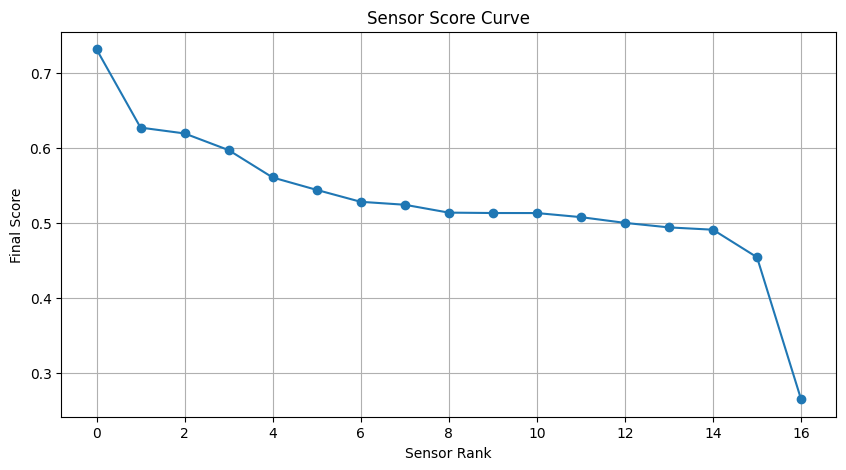

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(ranked["final_score"].values, marker='o')
plt.title("Sensor Score Curve")
plt.xlabel("Sensor Rank")
plt.ylabel("Final Score")
plt.grid(True)
plt.show()

In [16]:
threshold = 0.45

selected = ranked[ranked["final_score"] > threshold]

print("Selected sensors:")
print(selected[["final_score"]])

print(f"\nTotal selected sensors: {len(selected)}")

Selected sensors:
    final_score
17     0.731017
2      0.626727
4      0.618953
3      0.596793
8      0.560349
12     0.543845
9      0.527989
15     0.524073
7      0.513575
6      0.513070
10     0.513022
14     0.507588
5      0.499947
11     0.493933
16     0.490851
13     0.454201

Total selected sensors: 16


In [18]:
selected_sensor_names = df_clean.loc[selected.index, "sensor"]

print(selected_sensor_names.tolist())

['PY23', 'FT703', 'PDI702', 'PDI701', 'T702', 'T708', 'T703', 'T712', 'T701', 'FT704', 'T704', 'T711', 'FYI702', 'T706', 'T705', 'T709']


In [19]:
selected["sensor"] = df_clean.loc[selected.index, "sensor"].values

print(selected[["sensor", "final_score"]])

    sensor  final_score
17    PY23     0.731017
2    FT703     0.626727
4   PDI702     0.618953
3   PDI701     0.596793
8     T702     0.560349
12    T708     0.543845
9     T703     0.527989
15    T712     0.524073
7     T701     0.513575
6    FT704     0.513070
10    T704     0.513022
14    T711     0.507588
5   FYI702     0.499947
11    T706     0.493933
16    T705     0.490851
13    T709     0.454201


In [20]:
import json

sensor_list = selected["sensor"].tolist()

with open("../data/processed/selected_sensors.json", "w") as f:
    json.dump(sensor_list, f, indent=4)

print("✅ selected_sensors.json saved.")

✅ selected_sensors.json saved.


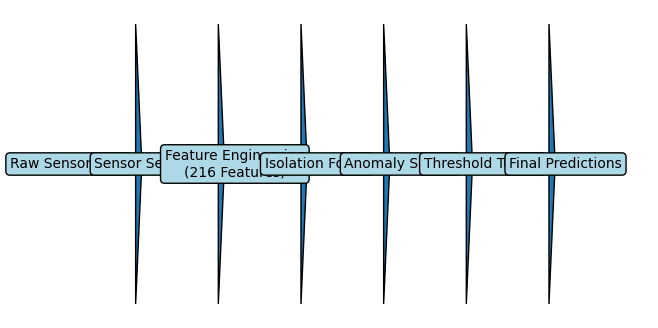

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.axis("off")

steps = [
    "Raw Sensor Data",
    "Sensor Selection",
    "Feature Engineering\n(216 Features)",
    "Isolation Forest",s
    "Anomaly Scores",
    "Threshold Tuning",
    "Final Predictions"
]

for i, step in enumerate(steps):
    plt.text(i, 0.5, step, ha='center', va='center',
             bbox=dict(boxstyle="round", facecolor="lightblue"))

    if i < len(steps)-1:
        plt.arrow(i+0.2, 0.5, 0.6, 0, head_width=0.05)

plt.xlim(-0.5, len(steps))
plt.savefig("model_workflow.png", dpi=300, bbox_inches='tight')
plt.show()